# *MICE for CATS* Replication Code
This python notebook replicates the methods in the *MICE for Cats* paper but modifies the code to fit in the application of Abstain/Clarify/Answer scenario.

### Setup

In [ ]:
import torch
import pandas as pd
import os
from datasets import load_from_disk
from google.colab import userdata

In [ ]:
# drive allocation
import os
from google.colab import drive
from datasets import load_dataset, Dataset, load_from_disk

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# env setup
BASE_PATH = r"CSCI 5980 8980 Project"

FINALIZER_PATH = f"/content/drive/MyDrive/{BASE_PATH}/Notebooks/MICE_Output/eval-1k"

layers_full_path = os.path.join(FINALIZER_PATH, "layers_full.csv")

summary_full_path = os.path.join(FINALIZER_PATH, "summary_full.csv")

In [ ]:
layers_full = pd.read_csv(layers_full_path)
summary_full = pd.read_csv(summary_full_path)

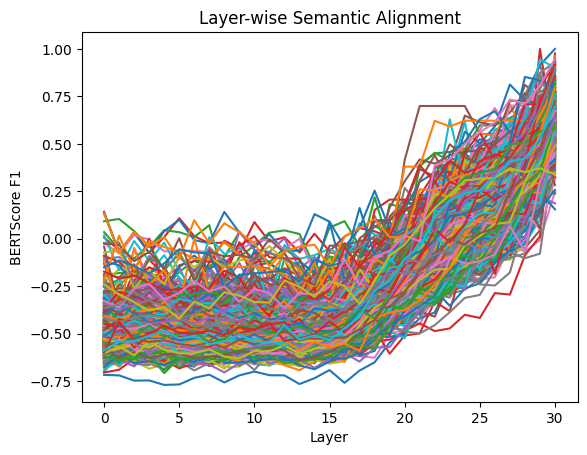

In [ ]:
# plot results
import matplotlib.pyplot as plt

plt.figure()

for qid in layers_full["question_id"].unique():
    subset = layers_full[layers_full["question_id"] == qid]
    plt.plot(subset["layer"], subset["f1"], label=f"QID {qid}")

plt.xlabel("Layer")
plt.ylabel("BERTScore F1")
plt.title("Layer-wise Semantic Alignment")
#plt.legend()
plt.show()

### Classifiers

In [ ]:
# data preprocessing
import pandas as pd
import numpy as np
import os

# one row per question, one column per layer (F1)
layer_pivot = (
    layers_full.pivot_table(index="question_id", columns="layer", values="f1")
    .sort_index(axis=1)
    .reset_index()
)
layer_pivot.columns = ["question_id"] + [f"f1_layer_{c}" for c in layer_pivot.columns[1:]]

df = summary_full.merge(layer_pivot, on="question_id")

In [ ]:
import joblib
import os

bundle_path = os.path.join(FINALIZER_PATH, "data_bundle.joblib")

# Load the dictionary
data = joblib.load(bundle_path)

# Unpack the arrays
X_train, y_train = data['train']
X_val, y_val = data['val']
X_test, y_test = data['test']
feature_cols = data['feature_names']
layer_cols = [c for c in feature_cols if c.startswith("f1_layer_")]

print("Arrays loaded successfully.")
print(f"X_train shape: {X_train.shape}")

Arrays loaded successfully.
X_train shape: (600, 32)


In [ ]:
# model training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

conf_idx = feature_cols.index("normalized_log_confidence")

# Normalise raw confidence to [0,1]
raw_conf = X_test[:, conf_idx]
raw_conf_norm = (raw_conf - raw_conf.min()) / (raw_conf.max() - raw_conf.min() + 1e-10)

# MICE Logistic Regression (L2, C=0.5)
mice_lr = LogisticRegression(C=0.5, max_iter=1000, random_state=42)
mice_lr.fit(X_train_s, y_train)

# MICE Random Forest (paper: 1000 trees, max_depth=20, max_features=10)
mice_rf = RandomForestClassifier(
    n_estimators=1000, max_depth=20, max_features=10,
    random_state=42, n_jobs=-1)
mice_rf.fit(X_train, y_train)

# Predicted probabilities P(correct)
p_hat_raw = raw_conf_norm
p_hat_lr  = mice_lr.predict_proba(X_test_s)[:, 1]
p_hat_rf  = mice_rf.predict_proba(X_test)[:, 1]

print("")
print("--- Classification Report — MICE LR ---")
print(classification_report(y_test, mice_lr.predict(X_test_s), target_names=["mismatch","match"]))
print("--- Classification Report — MICE RF ---")
print(classification_report(y_test, mice_rf.predict(X_test), target_names=["mismatch","match"]))


Train: 600  Val: 200  Test: 200

--- Classification Report — MICE LR ---
              precision    recall  f1-score   support

    mismatch       0.68      0.87      0.76       126
       match       0.57      0.31      0.40        74

    accuracy                           0.66       200
   macro avg       0.63      0.59      0.58       200
weighted avg       0.64      0.66      0.63       200

--- Classification Report — MICE RF ---
              precision    recall  f1-score   support

    mismatch       0.73      0.88      0.80       126
       match       0.68      0.43      0.53        74

    accuracy                           0.71       200
   macro avg       0.70      0.66      0.66       200
weighted avg       0.71      0.71      0.70       200



### Evaluation

#### smECE

##### Implementation

In [ ]:
# smECE implementation
import numpy as np

def silverman_bandwidth(p_hat: np.ndarray) -> float:
    n   = len(p_hat)
    std = np.std(p_hat, ddof=1)
    iqr = np.percentile(p_hat, 75) - np.percentile(p_hat, 25)
    s   = min(std, iqr / 1.34)
    return 0.9 * s * n ** (-0.2)

def nw_accuracy(p_eval, p_hat, y_true, bw):
    """Nadaraya–Watson local accuracy with reflected Gaussian kernel."""
    def gk(u): return np.exp(-0.5 * (u / bw) ** 2)
    k = gk(p_hat - p_eval) + gk(p_hat + p_eval) + gk(p_hat - (2 - p_eval))
    d = k.sum()
    return (k * y_true).sum() / d if d > 1e-12 else p_eval

def compute_smece(p_hat: np.ndarray, y_true: np.ndarray, n_eval: int = 500) -> float:
    bw        = silverman_bandwidth(p_hat)
    grid      = np.linspace(0, 1, n_eval)
    acc_curve = np.array([nw_accuracy(g, p_hat, y_true, bw) for g in grid])
    # Density weights via KDE
    def gk(u): return np.exp(-0.5 * (u / bw) ** 2)
    density = np.array([
        (gk(p_hat - g) + gk(p_hat + g) + gk(p_hat - (2 - g))).sum()
        for g in grid])
    density /= density.sum()
    return float(np.sum(density * np.abs(acc_curve - grid)))

smece_raw = compute_smece(p_hat_raw, y_test)
smece_lr  = compute_smece(p_hat_lr,  y_test)
smece_rf  = compute_smece(p_hat_rf,  y_test)

print(f"smECE  Raw Confidence : {smece_raw:.4f}")
print(f"smECE  MICE LR        : {smece_lr:.4f}")
print(f"smECE  MICE RF        : {smece_rf:.4f}")

smECE  Raw Confidence : 0.2806
smECE  MICE LR        : 0.0325
smECE  MICE RF        : 0.0212


##### Plots

In [ ]:
# plot setup
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

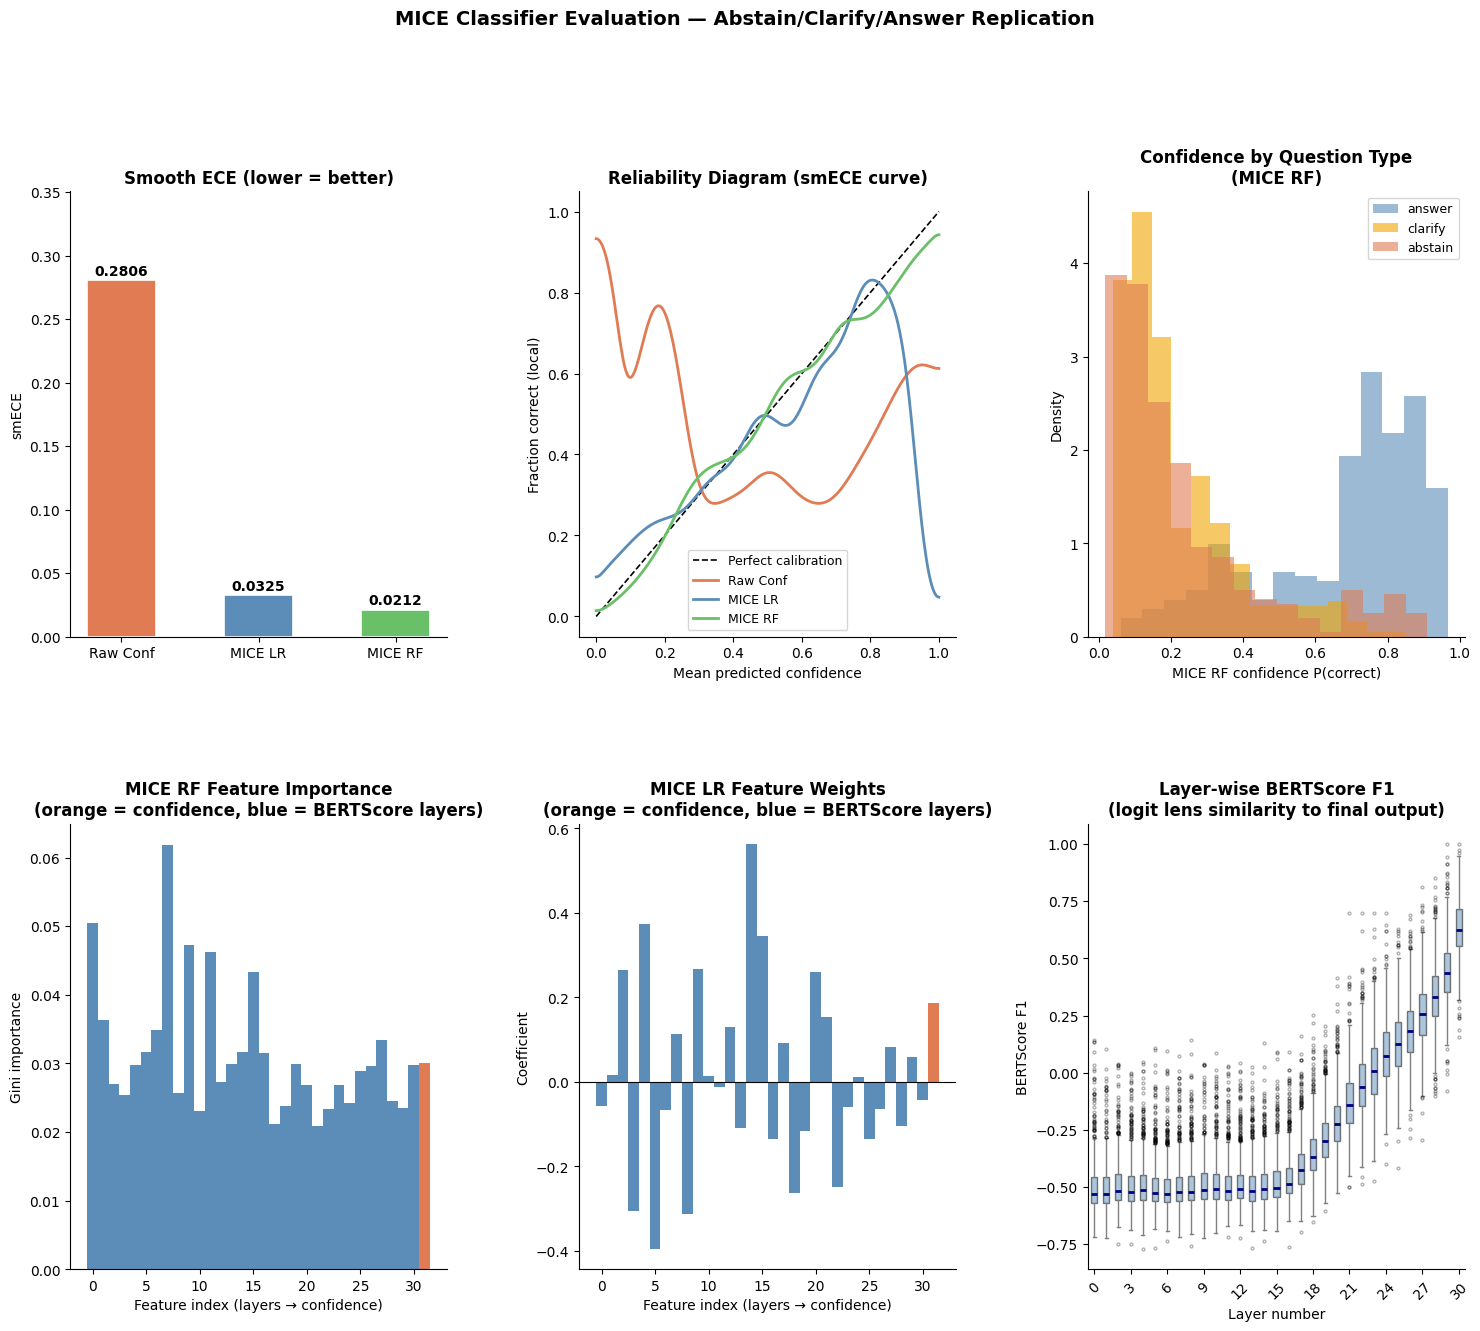

In [ ]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# 1. smECE bar chart
ax1 = fig.add_subplot(gs[0, 0])
labels  = ["Raw Conf", "MICE LR", "MICE RF"]
values  = [smece_raw, smece_lr, smece_rf]
colors  = ["#e07b54", "#5b8db8", "#6abf69"]
bars = ax1.bar(labels, values, color=colors, width=0.5, edgecolor="white", linewidth=1.2)
for b, v in zip(bars, values):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.4f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.set_title("Smooth ECE (lower = better)", fontweight="bold")
ax1.set_ylabel("smECE")
ax1.set_ylim(0, max(values) * 1.25)
ax1.spines[["top","right"]].set_visible(False)

# 2. Reliability diagram (calibration curve)
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot([0,1],[0,1], "k--", lw=1.2, label="Perfect calibration")
for p_hat, label, color in [
        (p_hat_raw, "Raw Conf",  "#e07b54"),
        (p_hat_lr,  "MICE LR",   "#5b8db8"),
        (p_hat_rf,  "MICE RF",   "#6abf69")]:
    bw   = silverman_bandwidth(p_hat)
    grid = np.linspace(0, 1, 300)
    acc  = np.array([nw_accuracy(g, p_hat, y_test, bw) for g in grid])
    ax2.plot(grid, acc, label=label, color=color, lw=2)
ax2.set_xlabel("Mean predicted confidence")
ax2.set_ylabel("Fraction correct (local)")
ax2.set_title("Reliability Diagram (smECE curve)", fontweight="bold")
ax2.legend(fontsize=9)
ax2.spines[["top","right"]].set_visible(False)

# 3. Confidence distribution by true type
ax3 = fig.add_subplot(gs[0, 2])
# Run RF over the full df so we can mask by type (p_hat_rf is test-set only)
X_full       = df[feature_cols].values.astype(np.float32)
all_rf_probs = mice_rf.predict_proba(X_full)[:, 1]

for qtype, color in [("answer","#5b8db8"),("clarify","#f0a500"),("abstain","#e07b54")]:
    mask = df["type"].values == qtype
    ax3.hist(all_rf_probs[mask], bins=15, alpha=0.6, color=color, label=qtype, density=True)
ax3.set_xlabel("MICE RF confidence P(correct)")
ax3.set_ylabel("Density")
ax3.set_title("Confidence by Question Type\n(MICE RF)", fontweight="bold")
ax3.legend(fontsize=9)
ax3.spines[["top","right"]].set_visible(False)

# 4. Feature importance (MICE RF Gini)
ax4 = fig.add_subplot(gs[1, 0])
importances = mice_rf.feature_importances_
ax4.bar(range(len(importances)), importances,
        color=["#e07b54" if c == "normalized_log_confidence" else "#5b8db8"
               for c in feature_cols],
        width=1.0)
ax4.set_xlabel("Feature index (layers → confidence)")
ax4.set_ylabel("Gini importance")
ax4.set_title("MICE RF Feature Importance\n(orange = confidence, blue = BERTScore layers)",
              fontweight="bold")
ax4.spines[["top","right"]].set_visible(False)

# 5. LR feature weights
ax5 = fig.add_subplot(gs[1, 1])
weights = mice_lr.coef_[0]
ax5.bar(range(len(weights)), weights,
        color=["#e07b54" if c == "normalized_log_confidence" else "#5b8db8"
               for c in feature_cols],
        width=1.0)
ax5.axhline(0, color="black", lw=0.8)
ax5.set_xlabel("Feature index (layers → confidence)")
ax5.set_ylabel("Coefficient")
ax5.set_title("MICE LR Feature Weights\n(orange = confidence, blue = BERTScore layers)",
              fontweight="bold")
ax5.spines[["top","right"]].set_visible(False)

# 6. BERTScore F1 across layers (box plot)
ax6 = fig.add_subplot(gs[1, 2])
layer_data = [df[c].values for c in layer_cols]
bp = ax6.boxplot(layer_data, patch_artist=True,
                 boxprops=dict(facecolor="#5b8db8", alpha=0.5),
                 medianprops=dict(color="navy", lw=2),
                 whiskerprops=dict(color="grey"),
                 capprops=dict(color="grey"),
                 flierprops=dict(marker="o", markersize=2, alpha=0.3))
ax6.set_xlabel("Layer number")
ax6.set_ylabel("BERTScore F1")
ax6.set_title("Layer-wise BERTScore F1\n(logit lens similarity to final output)",
              fontweight="bold")
ax6.set_xticks(range(1, len(layer_cols)+1, max(1, len(layer_cols)//8)))
ax6.set_xticklabels(range(0, len(layer_cols), max(1, len(layer_cols)//8)), rotation=45)
ax6.spines[["top","right"]].set_visible(False)

plt.suptitle("MICE Classifier Evaluation — Abstain/Clarify/Answer Replication",
             fontsize=14, fontweight="bold", y=1.01)
plt.show()

#### Utility

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

# -----------------------------
# Helpers
# -----------------------------
def minmax_fit(x):
    x = np.asarray(x, dtype=float)
    return float(np.min(x)), float(np.max(x))

def minmax_transform(x, lo, hi):
    x = np.asarray(x, dtype=float)
    return (x - lo) / (hi - lo + 1e-12)

def safe_roc_auc(y_true, scores):
    scores = np.asarray(scores, dtype=float)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, scores))

def safe_pr_auc(y_true, scores):
    scores = np.asarray(scores, dtype=float)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, scores))

# -----------------------------
# Confidence scores for train/val/test
# -----------------------------
raw_idx = feature_cols.index("normalized_log_confidence")

raw_train = X_train[:, raw_idx]
raw_val   = X_val[:, raw_idx]
raw_test  = X_test[:, raw_idx]

raw_lo, raw_hi = minmax_fit(raw_train)  # fit on train only to avoid leakage
p_raw_train = minmax_transform(raw_train, raw_lo, raw_hi)
p_raw_val   = minmax_transform(raw_val,   raw_lo, raw_hi)
p_raw_test  = minmax_transform(raw_test,  raw_lo, raw_hi)

p_lr_train = mice_lr.predict_proba(X_train_s)[:, 1]
p_lr_val   = mice_lr.predict_proba(X_val_s)[:, 1]
p_lr_test  = mice_lr.predict_proba(X_test_s)[:, 1]

p_rf_train = mice_rf.predict_proba(X_train)[:, 1]
p_rf_val   = mice_rf.predict_proba(X_val)[:, 1]
p_rf_test  = mice_rf.predict_proba(X_test)[:, 1]

y_train_bin = y_train
y_val_bin   = y_val
y_test_bin  = y_test

# -----------------------------
# AUC summary
# -----------------------------
auc_rows = []
for name, y_split, p_split in [
    ("Raw confidence", y_test_bin, p_raw_test),
    ("MICE LR",        y_test_bin, p_lr_test),
    ("MICE RF",        y_test_bin, p_rf_test),
]:
    auc_rows.append({
        "model": name,
        "ROC_AUC": safe_roc_auc(y_split, p_split),
        "PR_AUC": safe_pr_auc(y_split, p_split),
    })

auc_df = pd.DataFrame(auc_rows)
print("=== AUC on test split ===")
display(auc_df)

# -----------------------------
# Utility / risk profiles
# -----------------------------
# Interpretation:
#   answer  = trust the LLM's normal response
#   clarify = force a clarification question
#   abstain = force refusal / no answer
#
# Utilities are encoded as:
#   U(action | correct) and U(action | incorrect)
# so expected utility is p*U_correct + (1-p)*U_incorrect

RISK_PROFILES = {
    "low": {
        "answer_correct": 1.0,
        "answer_incorrect": -0.5,
        "clarify_correct": 0.10,
        "clarify_incorrect": -0.20,
        "abstain_correct": -0.30,
        "abstain_incorrect": -0.10,
    },
    "medium": {
        "answer_correct": 1.0,
        "answer_incorrect": -1.0,
        "clarify_correct": 0.10,
        "clarify_incorrect": -0.20,
        "abstain_correct": -0.30,
        "abstain_incorrect": -0.10,
    },
    "high": {
        "answer_correct": 1.0,
        "answer_incorrect": -9.0,
        "clarify_correct": 0.10,
        "clarify_incorrect": -0.20,
        "abstain_correct": -0.30,
        "abstain_incorrect": -0.10,
    },
}

def expected_utilities(p, u):
    """Return expected utility for each action at confidence p."""
    eu_answer = p * u["answer_correct"] + (1 - p) * u["answer_incorrect"]
    eu_clarify = p * u["clarify_correct"] + (1 - p) * u["clarify_incorrect"]
    eu_abstain = p * u["abstain_correct"] + (1 - p) * u["abstain_incorrect"]
    return {"answer": eu_answer, "clarify": eu_clarify, "abstain": eu_abstain}

def choose_action(p, u):
    eus = expected_utilities(p, u)
    return max(eus.items(), key=lambda kv: kv[1])[0]

def infer_thresholds(u, grid_size=10001):
    """
    Approximate the low/high thresholds implied by the utility table.
    Returns:
      t_low  = last confidence where abstain is best before clarify takes over
      t_high = first confidence where answer becomes best
    """
    grid = np.linspace(0.0, 1.0, grid_size)
    acts = np.array([choose_action(float(p), u) for p in grid])

    abstain_idx = np.where(acts == "abstain")[0]
    answer_idx  = np.where(acts == "answer")[0]

    t_low = float(grid[abstain_idx[-1]]) if len(abstain_idx) else 0.0
    t_high = float(grid[answer_idx[0]]) if len(answer_idx) else 1.0

    return t_low, t_high

def evaluate_policy(y_true, p_scores, u):
    p_scores = np.asarray(p_scores, dtype=float)

    actions = np.array([choose_action(float(p), u) for p in p_scores])

    realized = np.zeros_like(p_scores, dtype=float)
    realized[(actions == "answer") & (y_true == 1)] = u["answer_correct"]
    realized[(actions == "answer") & (y_true == 0)] = u["answer_incorrect"]
    realized[(actions == "clarify") & (y_true == 1)] = u["clarify_correct"]
    realized[(actions == "clarify") & (y_true == 0)] = u["clarify_incorrect"]
    realized[(actions == "abstain") & (y_true == 1)]  = u["abstain_correct"]
    realized[(actions == "abstain") & (y_true == 0)]  = u["abstain_incorrect"]

    t_low, t_high = infer_thresholds(u)

    return {
        "avg_utility": float(np.mean(realized)),
        "answer_rate": float(np.mean(actions == "answer")),
        "clarify_rate": float(np.mean(actions == "clarify")),
        "abstain_rate": float(np.mean(actions == "abstain")),
        "t_low": t_low,
        "t_high": t_high,
    }

# -----------------------------
# Utility summary on test split
# -----------------------------
model_scores = {
    "Raw confidence": p_raw_test,
    "MICE LR": p_lr_test,
    "MICE RF": p_rf_test,
}

rows = []
for risk_name, u in RISK_PROFILES.items():
    t_low, t_high = infer_thresholds(u)
    for model_name, scores in model_scores.items():
        out = evaluate_policy(y_test_bin, scores, u)
        rows.append({
            "risk": risk_name,
            "model": model_name,
            "ROC_AUC": safe_roc_auc(y_test_bin, scores),
            "PR_AUC": safe_pr_auc(y_test_bin, scores),
            "avg_utility": out["avg_utility"],
            "answer_rate": out["answer_rate"],
            "clarify_rate": out["clarify_rate"],
            "abstain_rate": out["abstain_rate"],
            "t_low": t_low,
            "t_high": t_high,
        })

results_df = pd.DataFrame(rows).sort_values(["risk", "model"]).reset_index(drop=True)

print("=== Utility summary on test split ===")
display(results_df)

print("=== Average utility (higher is better) ===")
display(results_df.pivot(index="model", columns="risk", values="avg_utility"))

=== AUC on test split ===


,model,ROC_AUC,PR_AUC
0,Raw confidence,0.540648,0.461374
1,MICE LR,0.671064,0.543471
2,MICE RF,0.750536,0.633356


=== Utility summary on test split ===


,risk,model,ROC_AUC,PR_AUC,avg_utility,answer_rate,clarify_rate,abstain_rate,t_low,t_high
0,high,MICE LR,0.671064,0.543471,-0.1345,0.005,0.860,0.135,0.1999,0.9073
1,high,MICE RF,0.750536,0.633356,-0.0760,0.000,0.770,0.230,0.1999,0.9073
2,high,Raw confidence,0.540648,0.461374,-0.3170,0.070,0.930,0.000,0.1999,0.9073
3,low,MICE LR,0.671064,0.543471,0.0625,0.710,0.155,0.135,0.1999,0.2500
4,low,MICE RF,0.750536,0.633356,0.1190,0.670,0.100,0.230,0.1999,0.2500
5,low,Raw confidence,0.540648,0.461374,0.0505,0.995,0.005,0.000,0.1999,0.2500
6,medium,MICE LR,0.671064,0.543471,-0.0565,0.255,0.610,0.135,0.1999,0.4706
7,medium,MICE RF,0.750536,0.633356,-0.0020,0.290,0.480,0.230,0.1999,0.4706
8,medium,Raw confidence,0.540648,0.461374,-0.2675,0.935,0.065,0.000,0.1999,0.4706


=== Average utility (higher is better) ===


risk,high,low,medium
model,,,
MICE LR,-0.1345,0.0625,-0.0565
MICE RF,-0.0760,0.1190,-0.0020
Raw confidence,-0.3170,0.0505,-0.2675


In [17]:
print(data['test'])

(array([[-0.31276906, -0.34874603, -0.36656728, ...,  0.4706413 ,
         0.5735714 , -0.16981964],
       [-0.6409685 , -0.6244631 , -0.6217413 , ...,  0.48503512,
         0.65026903, -0.16644365],
       [-0.5879229 , -0.5830464 , -0.55139357, ...,  0.4301202 ,
         0.7445615 , -0.16767731],
       ...,
       [-0.5633555 , -0.63850236, -0.5354811 , ...,  0.47489867,
         0.63754314, -0.16923332],
       [-0.4746465 , -0.44670716, -0.47185442, ...,  0.4956681 ,
         0.65571266, -0.2565575 ],
       [-0.47389498, -0.5367843 , -0.51562953, ...,  0.42858994,
         0.51508886, -0.23097533]], dtype=float32), array([1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1,
     

In [22]:
print(p_raw_test)
print(y_test_bin)
print(raw_test)
print(p_lr_test)
print(p_rf_test)

[0.73177685 0.73775071 0.73556772 0.87096639 0.96608283 0.66106921
 0.53953014 0.92053749 0.6221502  0.55716102 0.49935207 0.50994596
 0.6890424  0.67610098 1.00943414 0.69027346 0.88932201 0.80336866
 0.7114519  0.73617877 0.52458425 0.6871745  0.65116486 0.87009365
 0.8129852  0.70371356 0.66961775 0.78236036 0.55965235 0.61764903
 0.75344028 0.65656976 0.63696655 0.81987382 0.50208272 0.83316411
 0.59873642 0.78740394 0.7363784  0.76516076 0.78327435 0.74551046
 0.68273467 0.79431509 0.91281323 0.84058215 0.56096499 0.8066273
 0.20350504 0.77574988 0.75562224 0.8430302  0.79575599 0.82115504
 0.55272632 0.88659223 0.60103883 0.77527038 0.62316662 0.73693239
 0.87619978 0.67529919 0.68478661 0.89220864 0.93722644 0.47022817
 0.69973319 0.7370801  0.79453466 0.37241866 0.53736514 0.83528951
 0.82435983 0.5895724  0.40395311 0.74074691 0.83475645 0.80306569
 0.63848372 0.51926966 0.64381951 0.69381528 0.41433553 0.55154004
 0.97111238 0.71075379 0.78932246 0.71237691 0.48617002 0.55388